In [2]:
import pandas as pd

# upload simulated data from BCI toolbox (Zhu et al., 2024)
df = pd.read_excel('/Users/evans/Desktop/tics/fig2data/data.xlsx', sheet_name=1)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_tbw_param(csv_file, ax, label='A', title='', param_name='$p_{common}$',
                   cmap='rocket', fontsize=12):
    """
        Plot a single-panel version of the Temporal Binding Window (drawn on a provided ax).

        Parameters:
        - csv_file: str, path to the CSV file
        - ax: matplotlib subplot (Axes) object
        - label: subplot label (e.g., 'A', 'B', ...)
        - title: plot title
        - param_name: parameter name shown in the legend
        - cmap: colormap / color scheme
        """
    df = pd.read_excel('/Users/evans/Desktop/tics/fig2data/data.xlsx', sheet_name=csv_file)
    param_values = df.iloc[:, 0].values
    SOAs = df.columns[1:].astype(int)
    illusion_matrix = df.iloc[:, 1:].values
    colors = sns.color_palette(cmap, n_colors=len(param_values))

    for i, illusion_curve in enumerate(illusion_matrix):
        ax.plot(SOAs, illusion_curve, label=f"{param_name} = {param_values[i]:.2f}",
                linewidth=2.2, color=colors[i])

    
    ax.spines['left'].set_linewidth(3)   
    ax.spines['bottom'].set_linewidth(3) 
    ax.set_xlabel("SOA (ms)", fontsize=fontsize+4, fontweight='bold')
    ax.set_ylabel("Illusion Proportion", fontsize=fontsize+4, fontweight='bold')
    ax.set_title(title, fontsize=fontsize + 6, fontweight='bold')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(bbox_to_anchor=(1.02, 1),frameon=False, loc='upper left', fontsize=fontsize-2)
    ax.text(-0.12, 1.05, label, transform=ax.transAxes,
            fontsize=fontsize + 4, fontweight='bold')


In [8]:

def plot_tbw_grid(file_info_list, ncols=2, figsize=(12, 8), cmap='rocket'):
    
    n_plots = len(file_info_list)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten()

    for i, info in enumerate(file_info_list):
        plot_tbw_param(info['file'], axs[i], label=info['label'],
                       title=info['title'], param_name=info['param_name'], cmap=cmap)

    # 删除多余子图
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    fig.savefig("temporal_binding_all2.svg", 
            format='svg', 
            bbox_inches='tight',
            transparent=True) 
    plt.show()


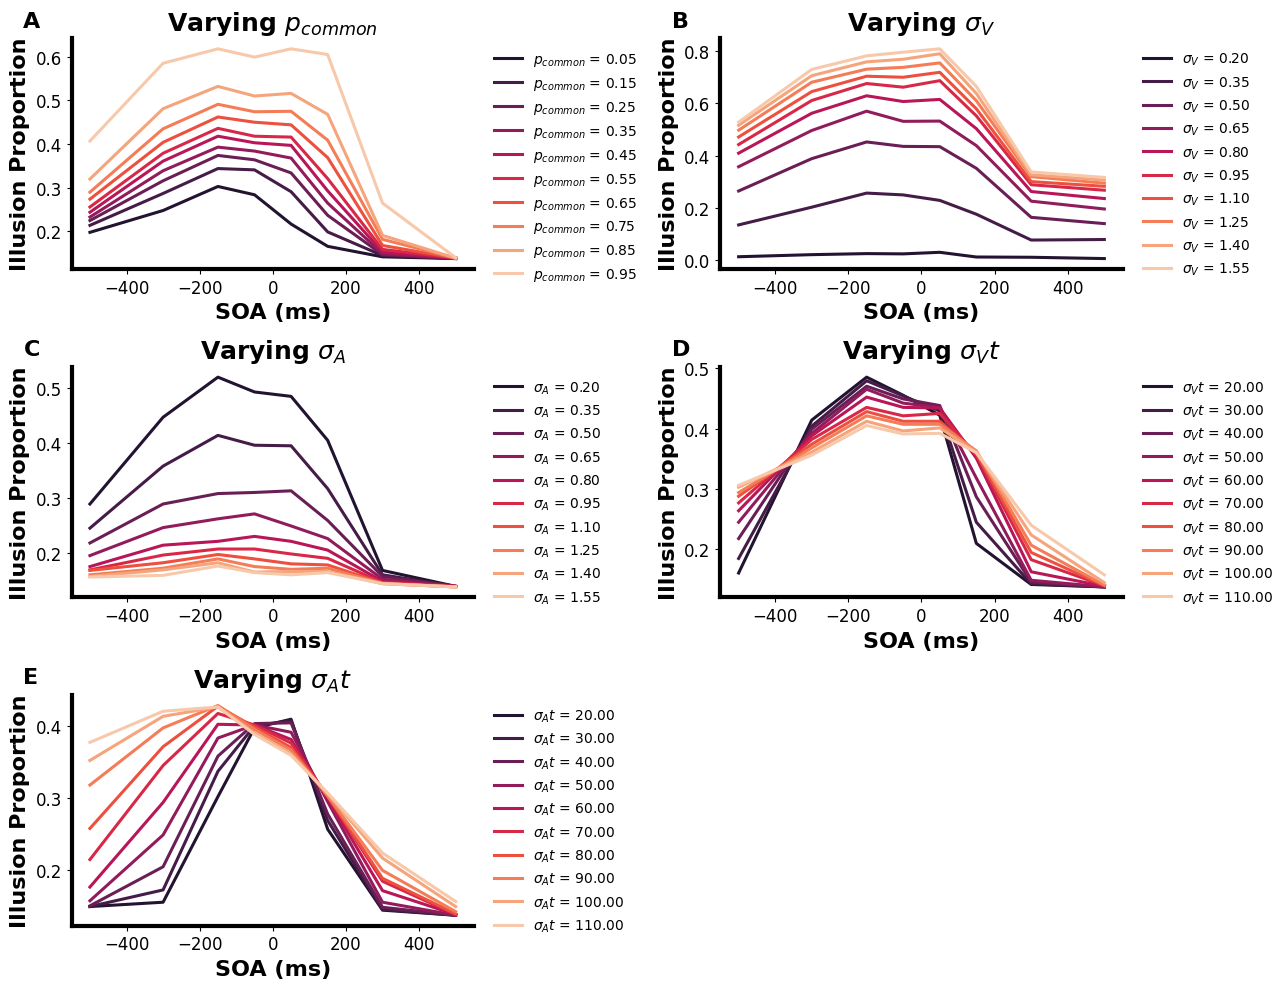

In [9]:
files = [
    {'file': 1, 'label': 'A', 'title': 'Varying $p_{common}$', 'param_name': '$p_{common}$'},
    {'file': 2, 'label': 'B', 'title': 'Varying $\sigma_V$', 'param_name': '$\sigma_V$'},
    {'file': 3, 'label': 'C', 'title': 'Varying $\sigma_A$', 'param_name': '$\sigma_A$'},
    {'file': 4, 'label': 'D', 'title': 'Varying $\sigma_Vt$', 'param_name': '$\sigma_Vt$'},
    {'file': 5, 'label': 'E', 'title': 'Varying $\sigma_At$', 'param_name': '$\sigma_At$'},
]

plot_tbw_grid(files, ncols=2, figsize=(13, 10))
